# Module 16: Financial Intelligence & Fintech Analytics
## Objective: Analyzing the modern financial landscape of the region.

Financial data requires high precision and specific ethical considerations. 
In this module, we will explore the mechanics of remittances, the logic of 
Islamic financial products, and the security of mobile payment systems.

### 1. Economic Trends: Foreign Inflows
We analyze remittance data to see how international transfers impact local 
liquidity. This often follows a seasonal pattern related to religious and 
cultural events.

In [11]:
import numpy as np
import pandas as pd
import pyarrow as pa

print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

# Create a small test dataframe to verify PyArrow
df = pd.DataFrame({'A': [1, 2, 3]})
df.to_feather('test.feather')
print("Environment Check: SUCCESS. You are ready for Module 2!")

NumPy Version: 2.4.4
Pandas Version: 3.0.2
Environment Check: SUCCESS. You are ready for Module 2!


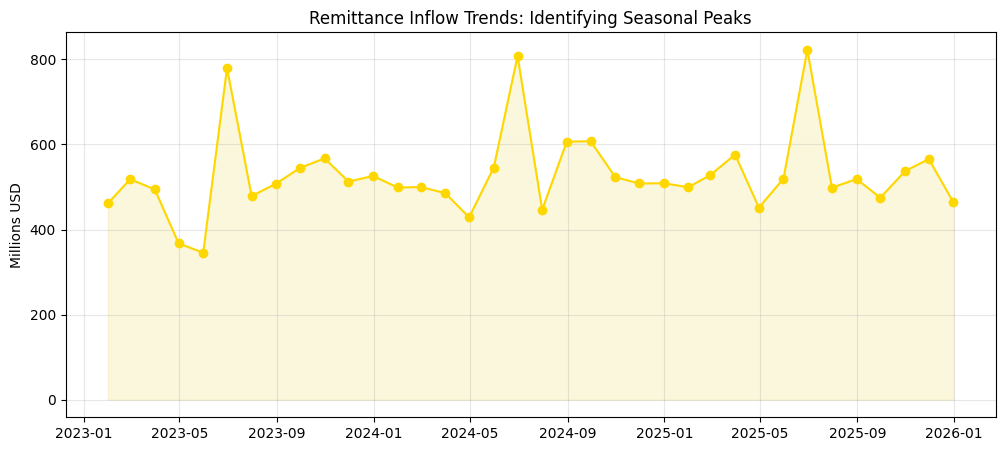

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulate 3 years of monthly remittance data (in Millions USD)
# Use 'ME' (Month End) instead of 'M'
dates = pd.date_range(start='2023-01-01', periods=36, freq='ME')
# Base flow + seasonal spikes for Eid months
base_flow = np.random.normal(500, 50, 36)
spikes = [5, 17, 29] # Indices representing annual peak months
for s in spikes:
    base_flow[s] += 250

remittance_df = pd.DataFrame({'Remittance_USD_M': base_flow}, index=dates)

# Visualization
plt.figure(figsize=(12, 5))
plt.plot(remittance_df, marker='o', color='gold', label='Monthly Inflow')
plt.fill_between(remittance_df.index, remittance_df['Remittance_USD_M'], color='khaki', alpha=0.3)
plt.title("Remittance Inflow Trends: Identifying Seasonal Peaks")
plt.ylabel("Millions USD")
plt.grid(True, alpha=0.3)
plt.show()

### 2. Determining Credit-Worthiness
For small business owners without a traditional credit score, we use a 
**Weighted Score** based on alternative behaviors.

In [13]:
# Sample applicant data
applicants = pd.DataFrame({
    'Business_ID': ['SME_001', 'SME_002', 'SME_003'],
    'Years_in_Business': [5, 1, 10],
    'Utility_Bill_Consistency': [0.95, 0.70, 0.99], # 1.0 is perfect
    'Mobile_Wallet_Volume': [50000, 10000, 150000]
})

# Weighted Scoring Logic
def calculate_credit_score(row):
    score = (row['Years_in_Business'] * 10) + \
            (row['Utility_Bill_Consistency'] * 40) + \
            (np.log1p(row['Mobile_Wallet_Volume']) * 5)
    return score

applicants['Final_Score'] = applicants.apply(calculate_credit_score, axis=1)

print("Alternative Credit Scoring Results:")
display(applicants.sort_values(by='Final_Score', ascending=False))

Alternative Credit Scoring Results:


,Business_ID,Years_in_Business,Utility_Bill_Consistency,Mobile_Wallet_Volume,Final_Score
2,SME_003,10,0.99,150000,199.191986
0,SME_001,5,0.95,50000,142.098991
1,SME_002,1,0.70,10000,84.052202


### 2. Determining Credit-Worthiness
For small business owners without a traditional credit score, we use a 
**Weighted Score** based on alternative behaviors.

In [14]:
# Sample applicant data
applicants = pd.DataFrame({
    'Business_ID': ['SME_001', 'SME_002', 'SME_003'],
    'Years_in_Business': [5, 1, 10],
    'Utility_Bill_Consistency': [0.95, 0.70, 0.99], # 1.0 is perfect
    'Mobile_Wallet_Volume': [50000, 10000, 150000]
})

# Weighted Scoring Logic
def calculate_credit_score(row):
    score = (row['Years_in_Business'] * 10) + \
            (row['Utility_Bill_Consistency'] * 40) + \
            (np.log1p(row['Mobile_Wallet_Volume']) * 5)
    return score

applicants['Final_Score'] = applicants.apply(calculate_credit_score, axis=1)

print("Alternative Credit Scoring Results:")
display(applicants.sort_values(by='Final_Score', ascending=False))

Alternative Credit Scoring Results:


,Business_ID,Years_in_Business,Utility_Bill_Consistency,Mobile_Wallet_Volume,Final_Score
2,SME_003,10,0.99,150000,199.191986
0,SME_001,5,0.95,50000,142.098991
1,SME_002,1,0.70,10000,84.052202


### 3. Profit-Sharing (Mudarabah) Logic
In Islamic Finance, the bank (Rab-ul-Maal) and the entrepreneur (Mudarib) 
agree on a **Profit Sharing Ratio (PSR)**.

In [15]:
# Project: Local Textile Expansion
total_profit = 250000 
psr_bank = 0.40      # 40%
psr_entrepreneur = 0.60 # 60%

def distribute_profit(profit, ratio_bank):
    bank_share = profit * ratio_bank
    entre_share = profit * (1 - ratio_bank)
    return bank_share, entre_share

bank, entrepreneur = distribute_profit(total_profit, psr_bank)

print(f"Total Project Profit: {total_profit} PKR")
print(f"Bank's Share (40%): {bank} PKR")
print(f"Entrepreneur's Share (60%): {entrepreneur} PKR")

Total Project Profit: 250000 PKR
Bank's Share (40%): 100000.0 PKR
Entrepreneur's Share (60%): 150000.0 PKR


### 4. Detecting Suspicious Activity
Mobile wallets are targets for scammers. We use **Z-Score** analysis to 
detect transactions that are significantly larger than a user's normal behavior.

In [16]:
# User's transaction history (Normal vs. Suspicious)
transactions = pd.Series([1200, 1500, 800, 2000, 1100, 1300, 75000]) # 75k is the anomaly

mean = transactions.mean()
std = transactions.std()

# Calculate Z-Scores
z_scores = (transactions - mean) / std

# Flag anything with a Z-Score > 2
fraud_flags = transactions[z_scores.abs() > 2]

print("Transaction Audit:")
print(f"User Average: {mean:.2f}")
print(f"Suspicious Transactions Detected:\n{fraud_flags}")

Transaction Audit:
User Average: 11842.86
Suspicious Transactions Detected:
6    75000
dtype: int64


### Student Exercise: The Fintech Analyst
**Goal**: Analyze mobile wallet usage in a local market.
1. Create a DataFrame for 100 users with columns: `Monthly_Transactions`, `Avg_Transfer_Amount`, and `Account_Age_Days`.
2. **Segment** the users: 
    - "Power User" if `Monthly_Transactions > 50`.
    - "New User" if `Account_Age_Days < 30`.
3. Calculate the **Total Volume** of money transferred per segment.
4. **Fraud Check**: Identify any user whose `Avg_Transfer_Amount` is more than 3 standard deviations above the group mean.
5. Create a **Plotly Bar Chart** showing the count of "Power Users" vs "Regular Users".